# Drosophila Whole-Brain LIF Model with Connectome Constraints

Author: RUI LUO
>
> **Objective**: 基于 FlyWire v783 连接组数据，从零构建 Leaky Integrate-and-Fire 全脑神经网络模型
> 
> **Reference**: Shiu et al. (2024) *A Drosophila computational brain model reveals sensorimotor processing*. Nature.

---

## Project Structure

```
~/lifmodel/
├── data_783/                              # FlyWire v783 connectome data
│   ├── proofread_connections_783.feather  # Synaptic connections (~2.7M records)
│   └── proofread_root_ids_783.npy         # Neuron IDs (~139K neurons)
├── LIF_simulation/
│   └── LIF_simulation.ipynb               # This notebook
└── Drosophila_brain_model/                # Reference implementation
```

---

## Model Overview

### Core Equations

**LIF Dynamics**: 
$$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + g_{exc} - g_{inh}$$

**Synaptic Currents**:
$$\tau_{syn} \frac{dg}{dt} = -g$$

**Connectome Constraint**: 
$$w_{ij} = n_{syn} \times W_{syn} \times sign_{NT}$$

其中 $sign_{NT} = +1$ (excitatory) 或 $-1$ (inhibitory)，由神经递质类型决定。

### Workflow

```
┌─────────────┐    ┌─────────────┐    ┌─────────────┐    ┌─────────────┐
│    Load     │───▶│    Build    │───▶│     Run     │───▶│   Analyze   │
│    Data     │    │   Network   │    │  Simulation │    │   Results   │
└─────────────┘    └─────────────┘    └─────────────┘    └─────────────┘
```

---

## Table of Contents

1. [Setup and Global Parameters](#1-setup-and-global-parameters)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Data Processing Functions](#3-data-processing-functions)
4. [Brian2 Network Functions](#4-brian2-network-functions)
5. [Model Class](#5-model-class)
6. [Model Validation](#6-model-validation)
7. [Experiments](#7-experiments)
8. [Results and Discussion](#8-results-and-discussion)

---

## Global Parameters

### LIF Neuron Parameters

| Parameter | Symbol | Value | Unit | Source |
|-----------|--------|-------|------|--------|
| Membrane time constant | τ_m | 20 | ms | Drosophila electrophysiology |
| Resting potential | V_rest | -52 | mV | Drosophila electrophysiology |
| Threshold potential | V_thresh | -45 | mV | Drosophila electrophysiology |
| Reset potential | V_reset | -52 | mV | Drosophila electrophysiology |
| Refractory period | τ_ref | 2 | ms | Drosophila electrophysiology |
| Synaptic time constant | τ_syn | 5 | ms | Alpha-synapse model |

### Synapse Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| W_syn | 0.275 mV | **唯一可调参数** - 单个突触引起的膜电位变化 |
| syn_threshold | 5 | FlyWire 标准阈值，少于 5 个突触视为噪声连接 |

### Neurotransmitter Classification

| Type | Neurotransmitters | Sign | Note |
|------|-------------------|------|------|
| **Inhibitory** | GABA, Glutamate | -1 | 注意：果蝇中 Glutamate 是抑制性的 |
| **Excitatory** | Acetylcholine | +1 | 果蝇主要的兴奋性神经递质 |
| **Modulatory** | Octopamine, Serotonin, Dopamine | +1 | 调节性递质，视为兴奋性处理 |

---

## Module Design

为保证代码**优雅、可复用、无冗余**，采用模块化设计：

### Data Processing Modules

| Module | Functions | Description |
|--------|-----------|-------------|
| **Data Loading** | `load_neuron_ids()`, `load_connectivity()`, `build_id_mapping()` | 加载数据，构建索引映射 |
| **NT Classification** | `get_dominant_nt()`, `classify_connection()`, `add_synapse_sign()` | 判断兴奋/抑制性（核心逻辑集中点）|
| **Neuron Selection** | `select_by_ids()`, `select_by_neuropil()`, `get_connected_subgraph()` | 筛选神经元子集 |
| **Connection Prep** | `filter_connections()`, `prepare_synapse_data()` | 准备 Brian2 所需数据格式 |

### Brian2 Network Modules

| Module | Functions | Description |
|--------|-----------|-------------|
| **Network Building** | `create_neuron_group()`, `create_synapses()`, `create_input_drive()`, `silence_neurons()` | 构建 Brian2 网络对象 |
| **Simulation** | `setup_monitors()`, `run_simulation()` | 运行仿真 |
| **Analysis** | `compute_firing_rates()`, `get_active_neurons()`, `extract_spike_times()` | 分析仿真结果 |
| **Visualization** | `plot_raster()`, `plot_firing_distribution()`, `plot_voltage_trace()` | 可视化 |

---

## Design Principles

1. **Single Responsibility** - 每个函数只做一件事
2. **DRY (Don't Repeat Yourself)** - 核心逻辑只写一次，通过函数调用复用
3. **Load Once, Use Many** - 数据只加载一次，存储后多次使用
4. **Vectorization First** - 优先使用 NumPy/Pandas 向量操作，避免 Python 循环
5. **Separation of Concerns** - Brian2 特定代码集中在 Module 4，便于维护


# 1. Setup and Global Parameters

本节完成：
- Import required libraries
- Define LIF model parameters
- Define synapse parameters  
- Define neurotransmitter classification rules
- Configure data paths

---

## 1.1 Import Libraries

In [1]:
# ------------------------------------------------------------------------------
# [Code Cell 1.1] Import Libraries
# ------------------------------------------------------------------------------

# Standard libraries
import os
import numpy as np       
import pandas as pd
from pathlib import Path     #跨平台路径处理
from typing import Dict, List, Set, Tuple, Optional, Union  #类型注解，提高代码可读性
import pyarrow.feather as feather #读取 Feather 文件，文件格式是二进制，读取和写入速度非常快
import pyarrow as pa

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Brian2 for neural simulation
import brian2
from brian2 import *

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully")
print(f"   Brian2 version: {brian2.__version__}")
print(f"   NumPy version: {np.__version__}")
print(f"   Pandas version: {pd.__version__}")


✅ All libraries imported successfully
   Brian2 version: 2.9.0
   NumPy version: 2.2.6
   Pandas version: 2.3.3


## 1.2 Global Parameters

In [2]:
# [Code Cell 1.2] Global Parameters
# ------------------------------------------------------------------------------

# =============================================================================
# LIF Neuron Parameters
# 来源：果蝇电生理文献 & Shiu et al. (2024)
# =============================================================================

LIF_PARAMS = {
    # Membrane dynamics
    'tau_m': 20.0,          # Membrane time constant (ms)
    'V_rest': -52.0,        # Resting potential (mV)
    'V_thresh': -45.0,      # Threshold potential (mV)
    'V_reset': -52.0,       # Reset potential (mV)
    'tau_ref': 2.2,         # Refractory period (ms) - Lazar et al 2021
    
    # Synaptic dynamics
    'tau_syn': 5.0,         # Synaptic time constant (ms)
}

# =============================================================================
# Synapse Parameters
# =============================================================================

SYNAPSE_PARAMS = {
    'W_syn': 0.275,         # Unit synaptic weight (mV)
                            # 这是模型中唯一的可调参数！
                            # 实际权重 = syn_count × W_syn × sign
    
    # Synaptic delay - Paul et al 2015
    't_dly': 1.8,           # Synaptic transmission delay (ms)

    
    'syn_threshold': 5,     # Minimum synapse count threshold
                            # FlyWire 标准：< 5 个突触视为噪声
}

# =============================================================================
# Neurotransmitter Classification （configuration（配置）：全局使用、很少修改、是“知识 / 规则 / 约定”）
# 注意：果蝇中 Glutamate 是抑制性的，与哺乳动物不同！
# =============================================================================

NT_CONFIG = {
    # Inhibitory neurotransmitters (sign = -1)
    'inhibitory': {'GABA', 'glutamate'},
    
    # Excitatory neurotransmitters (sign = +1)
    'excitatory': {'acetylcholine'},
    
    # Modulatory neurotransmitters (treated as excitatory, sign = +1)
    'modulatory': {'octopamine', 'serotonin', 'dopamine'},
    
    # Column name mapping in DataFrame
    'prob_columns': {
        'GABA': 'gaba_avg',
        'glutamate': 'glut_avg',
        'acetylcholine': 'ach_avg',
        'octopamine': 'oct_avg',
        'serotonin': 'ser_avg',
        'dopamine': 'da_avg',
    },
}

# =============================================================================
# Simulation Default Parameters
# =============================================================================

SIM_PARAMS = {
    'dt': 0.1,              # Time step (ms)
    'duration': 1000.0,     # Default simulation duration (ms) - matches Shiu
    'n_trials': 30,         # Number of trials for statistical analysis
    # 'activation_freq': 100, # Default activation frequency (Hz)
}

# ------------------------------------------------------------------------------
#  External Input Parameters
#  Parameters for Poisson input (simulating optogenetic activation or sensory input)
# ------------------------------------------------------------------------------


INPUT_PARAMS = {
    # Poisson input settings
    'r_poi': 150.0,         # Default Poisson rate (Hz) - activation frequency
    'f_poi': 250,           # Scaling factor for Poisson weight
                            # Effective weight = W_syn × f_poi = 0.275 × 250 = 68.75 mV
                            # This ensures input is strong enough to drive spiking
    
    # Secondary input (optional, for experiments with two input populations)
    'r_poi2': 0.0,          # Secondary Poisson rate (Hz), default off
    'activated_refractory': 0.0,  # Refractory period for activated neurons (ms)
                                   # Set to 0 so activated neurons can fire freely
}


# =============================================================================
# Print Parameter Summary
# =============================================================================

def print_params_summary():
    """Print a summary of all global parameters."""
    print("=" * 60)
    print("GLOBAL PARAMETERS SUMMARY")
    print("=" * 60)
    
    print("\n📌 LIF Neuron Parameters:")
    for key, val in LIF_PARAMS.items():   #.items()：返回一个 dict_items 视图对象，其中每个元素是一个 (key, value) 元组
        print(f"   {key:12s} = {val}")    #:12s ：并把 key 左对齐成固定宽度 12 的字符串
    
    print("\n📌 Synapse Parameters:")
    for key, val in SYNAPSE_PARAMS.items():
        print(f"   {key:15s} = {val}")
    
    print("\n📌 Neurotransmitter Classification:")
    print(f"   Inhibitory (-1): {NT_CONFIG['inhibitory']}")
    print(f"   Excitatory (+1): {NT_CONFIG['excitatory']}")
    print(f"   Modulatory (+1): {NT_CONFIG['modulatory']}")
    
    print("\n📌 Simulation Defaults:")
    for key, val in SIM_PARAMS.items():
        print(f"   {key:15s} = {val}")
    
    print("=" * 60)

print_params_summary()

GLOBAL PARAMETERS SUMMARY

📌 LIF Neuron Parameters:
   tau_m        = 20.0
   V_rest       = -52.0
   V_thresh     = -45.0
   V_reset      = -52.0
   tau_ref      = 2.2
   tau_syn      = 5.0

📌 Synapse Parameters:
   W_syn           = 0.275
   t_dly           = 1.8
   syn_threshold   = 5

📌 Neurotransmitter Classification:
   Inhibitory (-1): {'glutamate', 'GABA'}
   Excitatory (+1): {'acetylcholine'}
   Modulatory (+1): {'octopamine', 'serotonin', 'dopamine'}

📌 Simulation Defaults:
   dt              = 0.1
   duration        = 1000.0
   n_trials        = 30


## 1.3 Path Configuration

In [3]:
# ------------------------------------------------------------------------------
# [Code Cell 1.3] Path Configuration
# ------------------------------------------------------------------------------

# =============================================================================
# Data Paths
# 使用 Path 对象便于跨平台兼容
# =============================================================================

# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# Data paths
DATA_PATHS = {
    'data_dir': BASE_DIR / 'data_783',
    'connectivity': BASE_DIR / 'data_783' / 'proofread_connections_783.feather',
    'neuron_ids': BASE_DIR / 'data_783' / 'proofread_root_ids_783.npy',
    
    # Optional data files (if downloaded)
    'neuropil_pre': BASE_DIR / 'data_783' / 'per_neuron_neuropil_count_pre_783.feather',
    'neuropil_post': BASE_DIR / 'data_783' / 'per_neuron_neuropil_count_post_783.feather',
}

# Output paths
OUTPUT_PATHS = {
    'results_dir': BASE_DIR / 'LIF_simulation' / 'results',
    'figures_dir': BASE_DIR / 'LIF_simulation' / 'figures',
}

# =============================================================================
# Validate Paths
# =============================================================================

def validate_paths():
    """Check if required data files exist."""
    print("📁 Validating data paths...")
    
    required_files = ['connectivity', 'neuron_ids']
    all_exist = True
    
    for name in required_files:
        path = DATA_PATHS[name]
        exists = path.exists()      #检查这个路径指向的文件或目录，是否真的存在于文件系统中，返回boolean
        status = "✅" if exists else "❌"
        print(f"   {status} {name}: {path}")
        if not exists:
            all_exist = False
    
    # Create output directories if they don't exist
    for name, path in OUTPUT_PATHS.items():      #mkdir：在文件系统中创建一个目录（directory）（创建目标目录）
        path.mkdir(parents=True, exist_ok=True)  #parents=True ：保证存在一个母目录（没有就创建，有也不报错）（创建母目录）
        print(f"   📂 {name}: {path}")           #exist_ok = True：如果已经存在 = true 也不要报错（检查目标目录）
    
    if all_exist:
        print("\n✅ All required data files found!")
    else:
        print("\n❌ Some required files are missing!")
        print("   Please download from: https://zenodo.org/records/10676866")
    
    return all_exist

validate_paths()

📁 Validating data paths...
   ✅ connectivity: /Users/charlottel/mylibrary/connectome/lifmodel/data_783/proofread_connections_783.feather
   ✅ neuron_ids: /Users/charlottel/mylibrary/connectome/lifmodel/data_783/proofread_root_ids_783.npy
   📂 results_dir: /Users/charlottel/mylibrary/connectome/lifmodel/LIF_simulation/results
   📂 figures_dir: /Users/charlottel/mylibrary/connectome/lifmodel/LIF_simulation/figures

✅ All required data files found!


True

# 2. Data Loading and Exploration

本节完成：
- 加载 v783 连接组数据
- 理解数据结构和字段含义
- 进行基础统计分析
- 构建 ID 映射字典

---

## 2.1 Load Data Files

加载两个核心文件：
- `proofread_root_ids_783.npy` - 所有经过校对的神经元 ID
- `proofread_connections_783.feather` - 神经元之间的突触连接

In [4]:
def load_connectivity_data(filepath, chunk_size=500_000, verbose=True):
    """
    Load connectivity data from feather file using chunk streaming.
    
    使用 FlyWire 官方推荐的 chunk streaming 方法加载大型 feather 文件。
    
    Args:
        filepath: Path to the feather file
        chunk_size: Number of rows per chunk (default: 500,000)
        verbose: Whether to print progress (default: True)
    
    Returns:
        pd.DataFrame: Connectivity data with standard pandas types
    """
    # read_table: 一次性加载文件元数据和索引，但不直接转成 Pandas DataFrame，节省内存
    table = feather.read_table(filepath)
    num_rows = table.num_rows
    col_names = table.column_names
    
    if verbose:
        print(f"   Total rows: {num_rows:,}")
        print(f"   Chunk size: {chunk_size:,}")
    
    # Chunk streaming: 分块读取，逐列提取数据
    # 为每列创建一个列表来收集数据
    col_data = {col: [] for col in col_names}
    
    for i in range(0, num_rows, chunk_size):
        end_row = min(i + chunk_size, num_rows)
        chunk = table.slice(i, end_row - i)
        
        # 逐列提取数据
        for col_name in col_names:
            col = chunk.column(col_name)
            arr = col.combine_chunks()
            
            # 根据类型转换为 numpy/list
            if str(arr.type) == 'string':
                col_data[col_name].extend(arr.to_pylist())
            else:
                col_data[col_name].append(arr.to_numpy(zero_copy_only=False))
        
        if verbose:
            progress = end_row / num_rows * 100
            print(f"   Loading... {progress:5.1f}% ({end_row:,} / {num_rows:,})")
    
    # 合并数据
    if verbose:
        print("   Merging chunks...")
    
    final_data = {}
    for col_name in col_names:
        if isinstance(col_data[col_name][0], list) or isinstance(col_data[col_name][0], str):
            # string 类型：已经是 list，直接展平
            final_data[col_name] = col_data[col_name]
        else:
            # 数值类型：concatenate numpy arrays
            final_data[col_name] = np.concatenate(col_data[col_name])
    
    result = pd.DataFrame(final_data)
    
    if verbose:
        print("   ✅ Conversion complete")
    
    return result


# ---------------------------
# Load data
# ---------------------------
print("Loading FlyWire v783 connectome data...")
print("=" * 60)

print("\n📂 Loading neuron IDs...")
neuron_ids = np.load(DATA_PATHS['neuron_ids'])
print(f"   ✅ Loaded: {len(neuron_ids):,} neurons")

print("\n📂 Loading connectivity data (chunk streaming)...")
connectivity = load_connectivity_data(DATA_PATHS['connectivity'])
print(f"   ✅ Loaded: {len(connectivity):,} connection records")

# ---------------------------
# Summary
# ---------------------------
print("\n" + "=" * 60)
print("DATA LOADING COMPLETE")
print("=" * 60)
print(f"   Neurons:     {len(neuron_ids):,}")
print(f"   Connections: {len(connectivity):,}")

# .memory_usage(): 返回 DataFrame 每一列在内存中占用的字节数
# deep=True: 深入计算 object/string/ArrowDtype 等类型的真实占用
# / 1024**2: 1024**2 = 1,048,576 bytes，转换为 MB
print(f"   Memory:      {connectivity.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Loading FlyWire v783 connectome data...

📂 Loading neuron IDs...
   ✅ Loaded: 139,255 neurons

📂 Loading connectivity data (chunk streaming)...
   Total rows: 16,847,997
   Chunk size: 500,000
   Loading...   3.0% (500,000 / 16,847,997)
   Loading...   5.9% (1,000,000 / 16,847,997)
   Loading...   8.9% (1,500,000 / 16,847,997)
   Loading...  11.9% (2,000,000 / 16,847,997)
   Loading...  14.8% (2,500,000 / 16,847,997)
   Loading...  17.8% (3,000,000 / 16,847,997)
   Loading...  20.8% (3,500,000 / 16,847,997)
   Loading...  23.7% (4,000,000 / 16,847,997)
   Loading...  26.7% (4,500,000 / 16,847,997)
   Loading...  29.7% (5,000,000 / 16,847,997)
   Loading...  32.6% (5,500,000 / 16,847,997)
   Loading...  35.6% (6,000,000 / 16,847,997)
   Loading...  38.6% (6,500,000 / 16,847,997)
   Loading...  41.5% (7,000,000 / 16,847,997)
   Loading...  44.5% (7,500,000 / 16,847,997)
   Loading...  47.5% (8,000,000 / 16,847,997)
   Loading...  50.5% (8,500,000 / 16,847,997)
   Loading...  53.4% (9,000

## 2.2 Explore Neuron IDs

分析问题：
- Total number of neurons?
- Data type and range of IDs?
- Are IDs unique?

In [5]:
# ------------------------------------------------------------------------------
# [Code Cell 2.2] Explore Neuron IDs
# ------------------------------------------------------------------------------

print("=" * 60)
print("NEURON IDs EXPLORATION")
print("=" * 60)

print(f"\n📊 Basic Statistics:")
print(f"   Total neurons:  {len(neuron_ids):,}")
print(f"   Data type:      {neuron_ids.dtype}")
print(f"   Min ID:         {neuron_ids.min()}")
print(f"   Max ID:         {neuron_ids.max()}")

print(f"\n📊 Uniqueness Check:")
n_unique = len(np.unique(neuron_ids)) #用来找出数组中“所有不重复的元素”，并按默认顺序返回。
print(f"   Unique IDs:     {n_unique:,}")
print(f"   Is unique:      {n_unique == len(neuron_ids)}")

print(f"\n📊 Sample IDs (first 5):")
for i, nid in enumerate(neuron_ids[:5]): #for i, nid in enumerate（）：在遍历 iterable 的同时，自动生成索引i
    print(f"   [{i}] {nid}")

NEURON IDs EXPLORATION

📊 Basic Statistics:
   Total neurons:  139,255
   Data type:      uint64
   Min ID:         720575940596125868
   Max ID:         720575940661339777

📊 Uniqueness Check:
   Unique IDs:     139,255
   Is unique:      True

📊 Sample IDs (first 5):
   [0] 720575940621014292
   [1] 720575940621939071
   [2] 720575940624201033
   [3] 720575940608193884
   [4] 720575940621618859


## 2.3 Explore Connection Data

分析问题：
- What columns does the DataFrame have?
- How many connection records in total?
- Distribution of syn_count (synapse counts)?
- Meaning of neurotransmitter probability columns?

In [6]:
# ------------------------------------------------------------------------------
# [Code Cell 2.3] Explore Connection Data Structure
# ------------------------------------------------------------------------------

print("=" * 60)
print("CONNECTION DATA EXPLORATION")
print("=" * 60)

print(f"\n📊 DataFrame Shape: {connectivity.shape}")  # pandas DataFrame，可以理解为一个二维表格
print(f"   Rows (connections): {connectivity.shape[0]:,}")
print(f"   Columns:            {connectivity.shape[1]}")

print(f"\n📊 Column Names and Types:")
print("-" * 40)
for col in connectivity.columns:
    dtype = connectivity[col].dtype
    print(f"   {col:25s} {str(dtype):>10s}")

print(f"\n📊 First 3 Rows:")
print(connectivity.head(3).to_string())

print(f"\n📊 Memory Usage:")
mem_mb = connectivity.memory_usage(deep=True).sum() / 1024**2
print(f"   Total: {mem_mb:.1f} MB")

CONNECTION DATA EXPLORATION

📊 DataFrame Shape: (16847997, 10)
   Rows (connections): 16,847,997
   Columns:            10

📊 Column Names and Types:
----------------------------------------
   pre_pt_root_id                 int64
   post_pt_root_id                int64
   neuropil                      object
   syn_count                      int64
   gaba_avg                     float64
   ach_avg                      float64
   glut_avg                     float64
   oct_avg                      float64
   ser_avg                      float64
   da_avg                       float64

📊 First 3 Rows:
       pre_pt_root_id     post_pt_root_id neuropil  syn_count  gaba_avg   ach_avg  glut_avg   oct_avg   ser_avg    da_avg
0  720575940629970489  720575940631267655   AVLP_R          7  0.654330  0.023704  0.272418  0.048125  0.000472  0.000951
1  720575940623828999  720575940612348950    SLP_R          4  0.386517  0.024020  0.580512  0.000817  0.000857  0.007278
2  720575940624078484  720

## 2.4  Synapse Count Distribution

分析问题：
- Distribution of Synapse Counts

SYNAPSE COUNT (syn_count) ANALYSIS

📊 Statistics:
   Mean:    3.23
   Median:  1.0
   Std:     6.98
   Min:     1
   Max:     2405

📊 Percentiles:
   25th percentile: 1
   50th percentile: 1
   75th percentile: 3
   90th percentile: 7
   95th percentile: 11
   99th percentile: 27

📊 Threshold Analysis (syn_threshold = 5):
   Connections >= 5: 2,710,038 (16.1%)
   Connections <  5: 14,137,959 (83.9%)


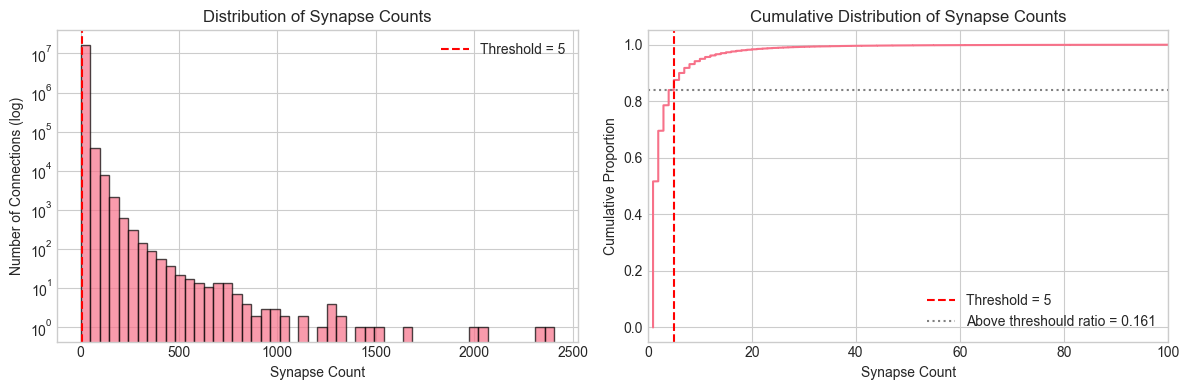

In [7]:
# ------------------------------------------------------------------------------
# [Code Cell 2.4] Synapse Count Distribution
# ------------------------------------------------------------------------------

print("=" * 60)
print("SYNAPSE COUNT (syn_count) ANALYSIS")
print("=" * 60)

syn_counts = connectivity['syn_count']  #connectivity['syn_count']  # 用列名（字符串）索引 → 返回整列，返回一个 **pandas Series**（一维数组）

#方括号 [] 的默认行为
#语法含义返回类型：df['col_name']选择一列 Series    df[['col1', 'col2']]选择多列DataFrame   df[0:5]选择前 5 行 (切片)DataFrame  df[condition]布尔筛选行  DataFrame
#明确指定：.loc 和 .iloc
#方法索引方式示例：.loc[row, col]用标签/名称  df.loc[0:5, 'syn_count']     .iloc[row, col]用整数位置df.iloc[0:5, 3]

print(f"\n📊 Statistics:")
print(f"   Mean:    {syn_counts.mean():.2f}")
print(f"   Median:  {syn_counts.median():.1f}")
print(f"   Std:     {syn_counts.std():.2f}")
print(f"   Min:     {syn_counts.min()}")
print(f"   Max:     {syn_counts.max()}")

print(f"\n📊 Percentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    val = syn_counts.quantile(p / 100)
    print(f"   {p}th percentile: {val:.0f}")

print(f"\n📊 Threshold Analysis (syn_threshold = {SYNAPSE_PARAMS['syn_threshold']}):")
above_thresh = (syn_counts >= SYNAPSE_PARAMS['syn_threshold']).sum()
below_thresh = (syn_counts < SYNAPSE_PARAMS['syn_threshold']).sum()
print(f"   Connections >= {SYNAPSE_PARAMS['syn_threshold']}: {above_thresh:,} ({100*above_thresh/len(syn_counts):.1f}%)")
print(f"   Connections <  {SYNAPSE_PARAMS['syn_threshold']}: {below_thresh:,} ({100*below_thresh/len(syn_counts):.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (log scale)
axes[0].hist(syn_counts, bins=50, edgecolor='black', alpha=0.7) #alpha：透明度（opacity）
axes[0].set_yscale('log')
axes[0].axvline(x=SYNAPSE_PARAMS['syn_threshold'], color='red', linestyle='--',  #ax → axis（坐标轴），v → vertical（垂直），line → 线
                label=f"Threshold = {SYNAPSE_PARAMS['syn_threshold']}")
axes[0].set_xlabel('Synapse Count')
axes[0].set_ylabel('Number of Connections (log)')
axes[0].set_title('Distribution of Synapse Counts')
axes[0].legend(loc='upper right')

# Cumulative distribution
sorted_counts = np.sort(syn_counts)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf) #CDF（Cumulative Distribution Function，累积分布函数）
axes[1].axvline(x=SYNAPSE_PARAMS['syn_threshold'], color='red', linestyle='--',
                label=f"Threshold = {SYNAPSE_PARAMS['syn_threshold']}")
axes[1].axhline(y=1-(above_thresh/len(syn_counts)), color='gray', linestyle=':',
                label=f"Above threshould ratio = {above_thresh/len(syn_counts):.3f}" ) #有连接的neurons pair占比（图上为1-比例）
axes[1].set_xlabel('Synapse Count')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('Cumulative Distribution of Synapse Counts')
axes[1].set_xlim(0, 100)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 2.5 Neurotransmitter Distribution Analysis

分析问题：
- Proportion of each neurotransmitter type?
- Ratio of excitatory vs inhibitory connections?

NEUROTRANSMITTER DISTRIBUTION ANALYSIS

📊 Dominant Neurotransmitter Distribution:
----------------------------------------
   acetylcholine   (+1) EXC  :  9,078,530 ( 53.9%)
   GABA            (-1) INH  :  3,567,600 ( 21.2%)
   glutamate       (-1) INH  :  3,287,461 ( 19.5%)
   dopamine        (+1) MOD  :    465,114 (  2.8%)
   serotonin       (+1) MOD  :    255,055 (  1.5%)
   octopamine      (+1) MOD  :    194,237 (  1.2%)

📊 Excitatory vs Inhibitory Summary:
   Excitatory (+1): 9,992,936 (59.3%)
   Inhibitory (-1): 6,855,061 (40.7%)
   E/I Ratio:       1.46


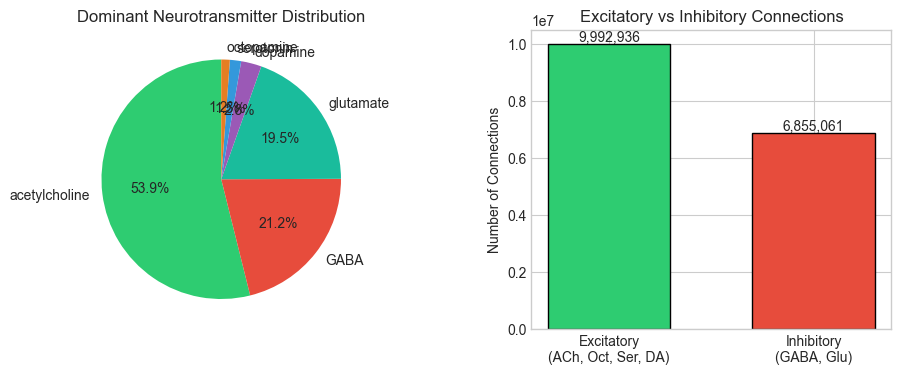

In [10]:
# ------------------------------------------------------------------------------
# [Code Cell 2.5] Neurotransmitter Distribution Analysis
#NOTICE：run Section 3.1 (add_synapse_sign) before this cell
# ------------------------------------------------------------------------------

def analyze_neurotransmitter_distribution(connectivity_df, nt_config, show_plot=True):
    """
    Analyze the distribution of neurotransmitters in the connectivity data.
    
    分析连接数据中神经递质的分布，计算兴奋性/抑制性连接比例。
    调用 add_synapse_sign() 进行 NT 分类，然后进行统计和可视化。
    
    Args:
        connectivity_df: DataFrame with neurotransmitter probability columns
        nt_config: NT_CONFIG dictionary with classification rules
        show_plot: Whether to display visualization
    
    Returns:
        dict: Summary statistics including counts and ratios
    """
    print("=" * 60)
    print("NEUROTRANSMITTER DISTRIBUTION ANALYSIS")
    print("=" * 60)

    # 3.1 function
    df_with_sign = add_synapse_sign(connectivity_df, nt_config)

    #Analysis results
    nt_counts = df_with_sign['dominant_nt'].value_counts()  # .value_counts(): 统计每个值出现的次数
    
    print(f"\n📊 Dominant Neurotransmitter Distribution:")
    print("-" * 40)
    for nt, count in nt_counts.items():
        pct = 100 * count / len(df_with_sign)
        if nt in nt_config['inhibitory']:
            sign = "(-1) INH"
        elif nt in nt_config['excitatory']:
            sign = "(+1) EXC"
        else:
            sign = "(+1) MOD"
        print(f"   {nt:15s} {sign:10s}: {count:>10,} ({pct:5.1f}%)")
    
    # Calculate excitatory vs inhibitory ratio
    exc_nts = nt_config['excitatory'] | nt_config['modulatory'] # |: 集合的并集 (union)
    inh_nts = nt_config['inhibitory']
    
    exc_count = sum([nt_counts.get(nt, 0) for nt in exc_nts])  # dict.get(key, default): 如果 key 不存在，返回 default
    inh_count = sum([nt_counts.get(nt, 0) for nt in inh_nts])
    total = exc_count + inh_count
    ei_ratio = exc_count / inh_count if inh_count > 0 else float('inf')
    
    print(f"\n📊 Excitatory vs Inhibitory Summary:")
    print(f"   Excitatory (+1): {exc_count:,} ({100*exc_count/total:.1f}%)")
    print(f"   Inhibitory (-1): {inh_count:,} ({100*inh_count/total:.1f}%)")
    print(f"   E/I Ratio:       {ei_ratio:.2f}")
    
    # Visualization
    if show_plot: 
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), 
                                  gridspec_kw={'width_ratios': [5, 3]}) # gridspec_kw: 设置子图宽度比例
        
        # Pie chart
        colors = {'acetylcholine': '#2ecc71', 'GABA': '#e74c3c', 'glutamate': '#1abc9c',
                  'dopamine': '#9b59b6', 'serotonin': '#3498db', 'octopamine': '#e67e22'}
        pie_colors = [colors.get(nt, '#95a5a6') for nt in nt_counts.index] # df.index: 行索引 (这里是 NT 名称)
        
        axes[0].pie(nt_counts.values, labels=nt_counts.index, autopct='%1.1f%%', # autopct: 百分比直接显示在饼块内部
                    colors=pie_colors, startangle=90)
        axes[0].set_title('Dominant Neurotransmitter Distribution')
        
        # Bar chart
        ei_labels = ['Excitatory\n(ACh, Oct, Ser, DA)', 'Inhibitory\n(GABA, Glu)']
        ei_values = [exc_count, inh_count]
        ei_colors = ['#2ecc71', '#e74c3c']
        bars = axes[1].bar(ei_labels, ei_values, color=ei_colors, 
                           edgecolor='black', width=0.6)
        axes[1].set_ylabel('Number of Connections')
        axes[1].set_title('Excitatory vs Inhibitory Connections')

        for bar, val in zip(bars, ei_values):  # zip: 将柱子对象和数值一一配对，方便在循环中同时使用。
            axes[1].text(bar.get_x() + bar.get_width()/2,   # 在柱子上方添加数值标签
                         bar.get_height() + 10000,
                         f'{val:,}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'nt_counts': nt_counts.to_dict(),
        'exc_count': exc_count,
        'inh_count': inh_count,
        'ei_ratio': ei_ratio,
    }


# Run analysis
nt_summary = analyze_neurotransmitter_distribution(connectivity, NT_CONFIG)


## 2.6 Build ID Mapping

构建双向映射字典，用于 root_id 和数组索引之间的快速转换：
- `id_to_idx`: root_id → array index
- `idx_to_id`: array index → root_id

In [11]:
# ------------------------------------------------------------------------------
# [Code Cell 2.6] Build ID Mapping
# ------------------------------------------------------------------------------

print("=" * 60)
print("BUILD ID MAPPING")
print("=" * 60)

# Create bidirectional mapping
id_to_idx = {nid: idx for idx, nid in enumerate(neuron_ids)}
idx_to_id = {idx: nid for idx, nid in enumerate(neuron_ids)}

print(f"\n✅ ID mapping created:")
print(f"   id_to_idx: {len(id_to_idx):,} entries (root_id → index)")
print(f"   idx_to_id: {len(idx_to_id):,} entries (index → root_id)")

# Verification
print(f"\n📊 Verification:")
sample_id = neuron_ids[100]
sample_idx = id_to_idx[sample_id]
recovered_id = idx_to_id[sample_idx]
print(f"   Sample root_id:     {sample_id}")
print(f"   Mapped to index:    {sample_idx}")
print(f"   Recovered root_id:  {recovered_id}")
print(f"   Round-trip correct: {sample_id == recovered_id}")

BUILD ID MAPPING

✅ ID mapping created:
   id_to_idx: 139,255 entries (root_id → index)
   idx_to_id: 139,255 entries (index → root_id)

📊 Verification:
   Sample root_id:     720575940660217473
   Mapped to index:    100
   Recovered root_id:  720575940660217473
   Round-trip correct: True


## 2.7 Data Summary

总结本节发现：
- Data scale and memory requirements
- Key observations
- Notes for subsequent implementation

In [16]:
# ------------------------------------------------------------------------------
# [Code Cell 2.7] Data Summary
# ------------------------------------------------------------------------------

print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│                    FlyWire v783 Data Summary                │
├─────────────────────────────────────────────────────────────┤
│  Neurons                                                    │
│    Total proofread neurons:     {len(neuron_ids):>10,}                  │
│    ID type:                     {str(neuron_ids.dtype):>10s}                  │
├─────────────────────────────────────────────────────────────┤
│  Connections                                                │
│    Total connection records:    {len(connectivity):>10,}                  │
│    Memory usage:                {mem_mb:>10.1f} MB               │
├─────────────────────────────────────────────────────────────┤
│  Synapse Statistics                                         │
│    Mean syn_count:              {syn_counts.mean():>10.2f}                  │
│    Median syn_count:            {syn_counts.median():>10.1f}                  │
│    Max syn_count:               {syn_counts.max():>10,}                  │
├─────────────────────────────────────────────────────────────┤
│  Neurotransmitter Balance                                   │
│    Excitatory connections:      {nt_summary['exc_count']:>10,} ({100*nt_summary['exc_count']/(nt_summary['exc_count']+nt_summary['inh_count']):>4.1f}%)          │
│    Inhibitory connections:      {nt_summary['inh_count']:>10,} ({100*nt_summary['inh_count']/(nt_summary['exc_count']+nt_summary['inh_count']):>4.1f}%)          │
│    E/I Ratio:                   {nt_summary['ei_ratio']:>10.2f}                  │
├─────────────────────────────────────────────────────────────┤
│  Key Observations                                           │
│    • Acetylcholine 是主要的兴奋性神经递质                       │
│    • GABA + Glutamate 构成抑制性连接                           │
│    • E/I 比例约为 {nt_summary['ei_ratio']:.1f}:1                                       │
│    • 大部分连接的 syn_count 较小（长尾分布）                     │
└─────────────────────────────────────────────────────────────┘
""")

print("\n✅ Section 2 complete! Data is ready for model building.")

DATA SUMMARY

┌─────────────────────────────────────────────────────────────┐
│                    FlyWire v783 Data Summary                │
├─────────────────────────────────────────────────────────────┤
│  Neurons                                                    │
│    Total proofread neurons:        139,255                  │
│    ID type:                         uint64                  │
├─────────────────────────────────────────────────────────────┤
│  Connections                                                │
│    Total connection records:    16,847,997                  │
│    Memory usage:                    2145.1 MB               │
├─────────────────────────────────────────────────────────────┤
│  Synapse Statistics                                         │
│    Mean syn_count:                    3.23                  │
│    Median syn_count:                   1.0                  │
│    Max syn_count:                    2,405                  │
├─────────────────────────

# 3. Data Processing Functions

本节实现数据处理相关的函数模块：
- Neurotransmitter classification
- Neuron selection
- Connection data preparation

---
## 3.1 Neurotransmitter Classification Functions

**核心逻辑**：判断每个连接是 excitatory (+1) 还是 inhibitory (-1)

**Functions**:
- `add_synapse_sign(df)` → pd.DataFrame

**Design Notes**:
- GABA 和 Glutamate 在果蝇中都是 inhibitory
- 使用向量化操作 (`np.where`) 避免逐行循环

In [9]:
# ------------------------------------------------------------------------------
# [Code Cell 3.1] Neurotransmitter Classification Functions
# ------------------------------------------------------------------------------

def add_synapse_sign(df, nt_config=None):
    """
    Add 'sign' and 'dominant_nt' columns to connectivity DataFrame (vectorized).
    
    批量为 DataFrame 添加突触符号列，使用向量化操作提高效率。
    这是 NT 分类的核心函数，供其他分析函数调用。
    
    Args:
        df: Connectivity DataFrame with NT probability columns
        nt_config: NT configuration dict (default: NT_CONFIG)
    
    Returns:
        pd.DataFrame: DataFrame with new 'sign' (+1/-1) and 'dominant_nt' columns
    """
    if nt_config is None:
        nt_config = NT_CONFIG
    
    prob_columns = nt_config['prob_columns']
    
    # # Get probability columns and NT name
    prob_cols = list(prob_columns.values())  # ['gaba_avg', 'ach_avg', ...]  # .values: 返回底层的 numpy array
    nt_names = list(prob_columns.keys())     # ['GABA', 'acetylcholine', ...]
    
    # For each connection, find the dominant neurotransmitter
    probs = df[prob_cols].values         #.values：Attribute属性（不是method，没有括号）：返回底层的 numpy array
    dominant_idx = probs.argmax(axis=1)  # argmax(axis=1): 在横向(column)方向寻找最大值的索引
    dominant_nt = np.array([nt_names[i] for i in dominant_idx])
    
    # whether nts is inhibition?
    inhibitory_nts = list(nt_config['inhibitory'])
    is_inhibitory = np.isin(dominant_nt, inhibitory_nts)
    
    # new dataframe
    df = df.copy()  # 避免 SettingWithCopyWarning
    df['sign'] = np.where(is_inhibitory, -1, +1) #np.where(条件, 符合条件的赋值, 不符合条件的赋值)。
    df['dominant_nt'] = dominant_nt #创建了一个名为 dominant_nt新colunm
    
    return df

# Test
print("✅ Section 3.1: Neurotransmitter Classification Functions")
print("   Core function: add_synapse_sign(df)")
print("\n   Testing on first 5 rows...")
test_df = connectivity.head(5).copy()
test_df = add_synapse_sign(test_df)
print(test_df[['syn_count', 'dominant_nt', 'sign']].to_string())


✅ Section 3.1: Neurotransmitter Classification Functions
   Core function: add_synapse_sign(df)

   Testing on first 5 rows...
   syn_count    dominant_nt  sign
0          7           GABA    -1
1          4      glutamate    -1
2          2  acetylcholine     1
3          2      glutamate    -1
4         15           GABA    -1


---

## 3.2 Neuron Selection Functions

**Functions**:
- `select_by_ids(neuron_ids, target_ids)` → Set
- `select_by_neuropil(connectivity, neuropil, direction)` → Set
- `get_connected_subgraph(connectivity, seed_ids, max_hops, direction)` → Set

**Use Cases**:
- 选择特定脑区（如 GNG, AL, MB）的神经元
- 获取与目标神经元相连的子网络，减少计算量

In [18]:
# ------------------------------------------------------------------------------
# [Code Cell 3.2] Neuron Selection Functions
# ------------------------------------------------------------------------------

def select_by_ids(all_ids, target_ids):
    """
    Select neurons by specific IDs.
    
    Args:
        all_ids: Array of all neuron IDs
        target_ids: List/array of target neuron IDs
    
    Returns:
        set: Set of valid target IDs (存在于 all_ids 中的)
    """
    all_ids_set = set(all_ids)
    valid_ids = set(target_ids) & all_ids_set
    
    invalid_count = len(target_ids) - len(valid_ids)
    if invalid_count > 0:
        print(f"   ⚠️ {invalid_count} IDs not found in neuron list")
    
    return valid_ids


def select_by_neuropil(connectivity_df, neuropil, direction='both'):
    """
    Select neurons that have connections in a specific neuropil.
    
    选择在指定脑区有连接的神经元。
    
    Args:
        connectivity_df: Connectivity DataFrame
        neuropil: Neuropil name (e.g., 'GNG', 'AL_R', 'MB')
        direction: 
            - 'pre': neurons that send output to this neuropil
            - 'post': neurons that receive input from this neuropil
            - 'both': neurons with any connection in this neuropil
    
    Returns:
        set: Set of neuron root IDs
    """
    mask = connectivity_df['neuropil'] == neuropil   #掩码，返回boolean，底层np向量化作比对非常快
    subset = connectivity_df[mask]
    
    if len(subset) == 0:
        print(f"   ⚠️ No connections found in neuropil '{neuropil}'")
        return set()
    
    if direction == 'pre':
        neurons = set(subset['pre_pt_root_id'].unique())  #.unique()只保留一次出现过的id
    elif direction == 'post':
        neurons = set(subset['post_pt_root_id'].unique())
    else:  # 'both'
        pre_neurons = set(subset['pre_pt_root_id'].unique())
        post_neurons = set(subset['post_pt_root_id'].unique())
        neurons = pre_neurons | post_neurons  #set：| union，& intersection, - difference(只在a不在b) , ^symmetric difference
    
    return neurons

#占位，后续预构建邻接表，变成纯粹的矩阵乘法，这在处理全脑数据（百万级连接）时几乎是瞬间完成
def get_connected_subgraph(connectivity_df, seed_ids, max_hops=2, direction='downstream'):
    """
    Get neurons connected to seed neurons within max_hops.
    
    获取从种子神经元出发，在指定跳数内的连通子图。
    使用 BFS (广度优先搜索) 算法。
    
    Args:
        connectivity_df: Connectivity DataFrame
        seed_ids: List of seed neuron IDs
        max_hops: Maximum number of hops (default: 2)
        direction: 'downstream', 'upstream', or 'both'
    
    Returns:
        set: Set of neuron root IDs in the subgraph
    """
    # TODO: 后续优化 - 当前实现对大数据较慢
    # 可考虑预先构建邻接表以加速查询
    
    current_neurons = set(seed_ids)
    all_neurons = set(seed_ids)
    
    for hop in range(max_hops):
        next_neurons = set()
        
        for neuron_id in current_neurons:
            if direction in ['downstream', 'both']:
                mask = connectivity_df['pre_pt_root_id'] == neuron_id
                downstream = set(connectivity_df.loc[mask, 'post_pt_root_id'])
                next_neurons |= downstream
            
            if direction in ['upstream', 'both']:
                mask = connectivity_df['post_pt_root_id'] == neuron_id
                upstream = set(connectivity_df.loc[mask, 'pre_pt_root_id'])
                next_neurons |= upstream
        
        new_neurons = next_neurons - all_neurons
        all_neurons |= new_neurons
        current_neurons = new_neurons
        
        if len(new_neurons) == 0:
            break
    
    return all_neurons


# Test
print("\n✅ Section 3.2: Neuron Selection Functions")
gng_neurons = select_by_neuropil(connectivity, 'GNG', direction='both')
print(f"   Neurons in GNG: {len(gng_neurons):,}")

neuropils = connectivity['neuropil'].unique()
print(f"   Available neuropils: {len(neuropils)}")
print(f"   Examples: {sorted(neuropils)[:5]}")


✅ Section 3.2: Neuron Selection Functions
   Neurons in GNG: 11,250
   Available neuropils: 79
   Examples: ['AL_L', 'AL_R', 'AME_L', 'AME_R', 'AMMC_L']


---

## 3.3 Connection Data Preparation Functions

**Functions**:
- `filter_connections(connectivity, neuron_subset, min_syn_count)` → pd.DataFrame
- `prepare_synapse_data(connectivity, id_to_idx)` → Dict

**Output Format** of `prepare_synapse_data`:
```python
{
    'exc_i': np.array,  # Excitatory presynaptic indices
    'exc_j': np.array,  # Excitatory postsynaptic indices  
    'exc_w': np.array,  # Excitatory weights
    'inh_i': np.array,  # Inhibitory presynaptic indices
    'inh_j': np.array,  # Inhibitory postsynaptic indices
    'inh_w': np.array,  # Inhibitory weights
}
```

In [19]:
# ------------------------------------------------------------------------------
# [Code Cell 3.3] Connection Data Preparation Functions
# ------------------------------------------------------------------------------

def filter_connections(connectivity_df, neuron_subset=None, min_syn_count=5):
    """
    Filter connectivity data.
    
    过滤连接数据，只保留满足条件的连接。
    
    Args:
        connectivity_df: Full connectivity DataFrame
        neuron_subset: Set of neuron IDs to keep (None = keep all)
        min_syn_count: Minimum synapse count threshold
    
    Returns:
        pd.DataFrame: Filtered connectivity data
    """
    df = connectivity_df
    
    # 过滤低于阈值的连接
    if min_syn_count > 0:
        df = df[df['syn_count'] >= min_syn_count]
    
    # 过滤神经元子集
    if neuron_subset is not None:
        neuron_set = set(neuron_subset)
        mask = (df['pre_pt_root_id'].isin(neuron_set) & 
                df['post_pt_root_id'].isin(neuron_set))   #提取 input neuron_subset 内部的相互连接
        df = df[mask]
    
    return df.reset_index(drop=True) #drop=True：意思是“把旧的、断掉的索引直接丢掉”


def prepare_synapse_data(connectivity_df, id_to_idx_map, nt_config=None):
    """
    Prepare synapse data for Brian2 network construction.
    
    将 DataFrame 格式的连接数据转换为 Brian2 所需的数组格式。
    这是连接 connectivity DataFrame 和 Brian2 网络的核心函数。
    
    Args:
        connectivity_df: Connectivity DataFrame
        id_to_idx_map: Dict mapping root_id to array index
        nt_config: NT configuration (default: NT_CONFIG)
    
    Returns:
        dict: {
            'exc_i': presynaptic indices (excitatory),
            'exc_j': postsynaptic indices (excitatory),
            'exc_w': weights in syn_count (excitatory),
            'inh_i': presynaptic indices (inhibitory),
            'inh_j': postsynaptic indices (inhibitory),
            'inh_w': weights in syn_count (inhibitory),
            'n_exc': number of excitatory connections,
            'n_inh': number of inhibitory connections,
        }
    """
    # 添加 sign 列（如果没有）
    if 'sign' not in connectivity_df.columns:
        connectivity_df = add_synapse_sign(connectivity_df, nt_config) #3.1的method function，return的是copy的新df
    
    # 只保留两端神经元都在映射中的连接
    valid_mask = (connectivity_df['pre_pt_root_id'].isin(id_to_idx_map) & 
                  connectivity_df['post_pt_root_id'].isin(id_to_idx_map))
    df = connectivity_df[valid_mask].copy()
    
    # 转换 root_id → index
    df['pre_idx'] = df['pre_pt_root_id'].map(id_to_idx_map)  #.map()：映射，把一列里的每一个值，按一个“查表规则”，换成另一个值。
    df['post_idx'] = df['post_pt_root_id'].map(id_to_idx_map) #如果 df 里还没有 'pre_idx' 这一列，执行这一行代码时，Pandas 会自动为你创建这个新列。
    
    # 分离兴奋性和抑制性
    exc_df = df[df['sign'] == 1]
    inh_df = df[df['sign'] == -1]
    
    return {
        'exc_i': exc_df['pre_idx'].values.astype(np.int32),
        'exc_j': exc_df['post_idx'].values.astype(np.int32),
        'exc_w': exc_df['syn_count'].values.astype(np.float64),
        'inh_i': inh_df['pre_idx'].values.astype(np.int32),
        'inh_j': inh_df['post_idx'].values.astype(np.int32),
        'inh_w': inh_df['syn_count'].values.astype(np.float64),
        'n_exc': len(exc_df),
        'n_inh': len(inh_df),
    }


# Test
print("\n✅ Section 3.3: Connection Data Preparation Functions")

filtered_conn = filter_connections(connectivity, min_syn_count=5)
print(f"   Filtered connections (syn_count >= 5): {len(filtered_conn):,}")

# 小规模测试
print("   Testing prepare_synapse_data() on 1000 connections...")
test_synapse_data = prepare_synapse_data(filtered_conn.head(1000), id_to_idx)
print(f"   Excitatory: {test_synapse_data['n_exc']:,}")
print(f"   Inhibitory: {test_synapse_data['n_inh']:,}")




✅ Section 3.3: Connection Data Preparation Functions
   Filtered connections (syn_count >= 5): 2,710,038
   Testing prepare_synapse_data() on 1000 connections...
   Excitatory: 608
   Inhibitory: 392


In [20]:
# ------------------------------------------------------------------------------
# [Code Cell 3.4] Section 3 Summary
# ------------------------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 3 COMPLETE: Data Processing Functions")
print("=" * 60)
print("""
Functions defined:

  📦 NT Classification (Cell 3.1):
     • get_dominant_nt(row)
     • classify_connection(row)
     • add_synapse_sign(df)  ← 向量化，高效

  📦 Neuron Selection (Cell 3.2):
     • select_by_ids(all_ids, target_ids)
     • select_by_neuropil(connectivity_df, neuropil, direction)
     • get_connected_subgraph(connectivity_df, seed_ids, max_hops)

  📦 Connection Preparation (Cell 3.3):
     • filter_connections(connectivity_df, neuron_subset, min_syn_count)
     • prepare_synapse_data(connectivity_df, id_to_idx_map)  ← 核心函数

Pre-existing from Section 2:
     • load_connectivity_data()  → Cell 2.1
     • build_id_mapping()        → Cell 2.5
     • id_to_idx, idx_to_id      → Cell 2.5
""")


SECTION 3 COMPLETE: Data Processing Functions

Functions defined:

  📦 NT Classification (Cell 3.1):
     • get_dominant_nt(row)
     • classify_connection(row)
     • add_synapse_sign(df)  ← 向量化，高效

  📦 Neuron Selection (Cell 3.2):
     • select_by_ids(all_ids, target_ids)
     • select_by_neuropil(connectivity_df, neuropil, direction)
     • get_connected_subgraph(connectivity_df, seed_ids, max_hops)

  📦 Connection Preparation (Cell 3.3):
     • filter_connections(connectivity_df, neuron_subset, min_syn_count)
     • prepare_synapse_data(connectivity_df, id_to_idx_map)  ← 核心函数

Pre-existing from Section 2:
     • load_connectivity_data()  → Cell 2.1
     • build_id_mapping()        → Cell 2.5
     • id_to_idx, idx_to_id      → Cell 2.5



# 4. Brian2 Network Functions

本节实现 Brian2 相关的函数模块：
- Network construction
- Simulation execution
- Result analysis
- Visualization

---

## 4.1 Network Building Functions

**Functions**:
- `create_neuron_group(n_neurons, params)` → brian2.NeuronGroup
- `create_synapses(neuron_group, synapse_data, params)` → Tuple[Synapses, Synapses]
- `create_input_drive(neuron_group, target_indices, frequency)` → Tuple[PoissonGroup, Synapses]
- `silence_neurons(neuron_group, target_indices)` → None

**LIF Equations**:
```
dv/dt = (V_rest - v + g_exc - g_inh) / tau_m : volt
dg_exc/dt = -g_exc / tau_syn : volt
dg_inh/dt = -g_inh / tau_syn : volt
```

In [21]:
# ------------------------------------------------------------------------------
# [Code Cell 4.1] Network Building Functions
# ------------------------------------------------------------------------------

def create_neuron_group(n_neurons, params=None):
    """
    Create a LIF neuron group.
    
    创建 Leaky Integrate-and-Fire 神经元 组。
    
    Args:
        n_neurons: Number of neurons
        params: LIF parameters dict (default: LIF_PARAMS)
    
    Returns:
        brian2.NeuronGroup: LIF neuron group
    
    LIF Equations:
        τ_m * dV/dt = -(V - V_rest) + g_exc - g_inh
        τ_syn * dg_exc/dt = -g_exc
        τ_syn * dg_inh/dt = -g_inh
    """
    if params is None:
        params = LIF_PARAMS
    
    # 定义 LIF 方程    #假设单位电导对应单位电流，所以直接加减
    eqs = '''
    dv/dt = (V_rest - v + g_exc - g_inh) / tau_m : volt (unless refractory)  
    dg_exc/dt = -g_exc / tau_syn : volt (unless refractory)
    dg_inh/dt = -g_inh / tau_syn : volt (unless refractory)
    rfc : second
    '''
    
    # 创建神经元组，是python object，封装了神经元的数量、动力学方程和更新逻辑。
    neurons = NeuronGroup(
        n_neurons,
        eqs,
        threshold='v > V_thresh',      
        reset='v = V_reset, g_exc = 0*mV; g_inh = 0*mV',          
        refractory='rfc',  
        method='linear',                # 针对线性方程优化的解析解方法，brain2里面有好几种不同的方法，各有特点
        namespace={                     #{eqs里名字 : Python 对象 }
            'V_rest': params['V_rest'] * mV,
            'V_thresh': params['V_thresh'] * mV,
            'V_reset': params['V_reset'] * mV,
            'tau_m': params['tau_m'] * ms,
            'tau_syn': params['tau_syn'] * ms,
        }
    )
    
    # initialize as rest v
    neurons.v = params['V_rest'] * mV
    neurons.g_exc = 0 * mV
    neurons.g_inh = 0 * mV
    neurons.rfc = params['tau_ref'] * ms
    
    return neurons


def create_synapses(neuron_group, synapse_data, syn_params=None):
    """
    Create excitatory and inhibitory synapses.
    
    根据 synapse_data 创建兴奋性和抑制性突触连接。
    
    Args:
        neuron_group: Brian2 NeuronGroup
        synapse_data: dict from prepare_synapse_data()
        params: Synapse parameters (default: SYNAPSE_PARAMS)
    
    Returns:
        tuple: (syn_exc, syn_inh) - Excitatory and inhibitory Synapses objects
    """
    if params is None:
        params = SYNAPSE_PARAMS
    
    W_syn = params['W_syn'] * mV  # 单位突触权重
    t_delay = syn_params['t_dly'] * ms
    
    # 创建兴奋性突触
    # on_pre: 当突触前神经元发放时，增加突触后神经元的 g_exc
    syn_exc = Synapses(
        neuron_group, neuron_group,
        model='w : volt',   # 每个突触有自己的权重
        on_pre='g_exc_post += w',  # 突触前 spike → 增加 g_exc
        delay=t_delay,
        name='excitatory_synapses'
    )

    
    # 创建抑制性突触
    syn_inh = Synapses(
        neuron_group, neuron_group,
        model='w : volt',
        on_pre='g_inh_post += w', # 突触前 spike → 增加 g_inh
        delay=t_delay,
        name='inhibitory_synapses'
    )
    
    # 连接兴奋性突触
    if synapse_data['n_exc'] > 0:
        syn_exc.connect(i=synapse_data['exc_i'], j=synapse_data['exc_j'])
        # 权重 = syn_count × W_syn
        syn_exc.w = synapse_data['exc_w'] * W_syn
    
    # 连接抑制性突触
    if synapse_data['n_inh'] > 0:
        syn_inh.connect(i=synapse_data['inh_i'], j=synapse_data['inh_j'])
        syn_inh.w = synapse_data['inh_w'] * W_syn
    
    return syn_exc, syn_inh

def create_input_drive(neuron_group, target_indices, input_params=None, syn_params=None):
    """
    Create external Poisson input drive (simulating optogenetic activation).
    
    Uses PoissonInput to directly inject current into target neurons.
    Weight = W_syn × f_poi (default: 0.275 × 250 = 68.75 mV per spike)
    
    Args:
        neuron_group: Brian2 NeuronGroup
        target_indices: List/array of neuron indices to activate
        input_params: Input parameters (default: INPUT_PARAMS)
        syn_params: Synapse parameters for W_syn (default: SYNAPSE_PARAMS)
    
    Returns:
        tuple: (list of PoissonInput objects, modified neuron_group)
    """
    if input_params is None:
        input_params = INPUT_PARAMS
    if syn_params is None:
        syn_params = SYNAPSE_PARAMS
    
    if len(target_indices) == 0:
        return [], neuron_group
    
    # Calculate input weight: W_syn × f_poi
    input_weight = syn_params['W_syn'] * input_params['f_poi'] * mV  #Poisson 输入的放大因子 f_poi
    rate = input_params['r_poi'] * Hz
    
    poisson_inputs = []
    for idx in target_indices:
        # Create PoissonInput for each target neuron
        poi = PoissonInput(
            target=neuron_group[idx],
            target_var='v',  #直接加在膜电位上
            N=1,
            rate=rate,
            weight=input_weight
        )
        poisson_inputs.append(poi)
        
        # Set refractory period to 0 for activated neurons
        # This allows them to fire freely in response to input
        neuron_group.rfc[idx] = input_params['activated_refractory'] * ms
    
    return poisson_inputs, neuron_group
    

def silence_neurons(neuron_indices, syn_exc, syn_inh):
    """
    Silence neurons by setting all their output synaptic weights to 0.
    
    This is the proper way to silence neurons - by removing their
    ability to influence downstream neurons.
    
    Args:
        neuron_indices: List/array of neuron indices to silence
        syn_exc: Excitatory Synapses object
        syn_inh: Inhibitory Synapses object
    
    Returns:
        tuple: (modified syn_exc, modified syn_inh)
    """
    for idx in neuron_indices:
        # Silence excitatory outputs
        syn_exc.w[f'{idx} == i'] = 0 * mV
        # Silence inhibitory outputs
        syn_inh.w[f'{idx} == i'] = 0 * mV
    
    return syn_exc, syn_inh


print("✅ Section 4.1: Network Building Functions")
print("   • create_neuron_group(n_neurons, params)")
print("   • create_synapses(neuron_group, synapse_data, params)")
print("   • create_input_drive(neuron_group, target_indices, frequency)")
print("   • silence_neurons(neuron_group, target_indices)")



✅ Section 4.1: Network Building Functions
   • create_neuron_group(n_neurons, params)
   • create_synapses(neuron_group, synapse_data, params)
   • create_input_drive(neuron_group, target_indices, frequency)
   • silence_neurons(neuron_group, target_indices)


---

## 4.2 Simulation Functions

**Functions**:
- `setup_monitors(neuron_group, record_voltage)` → Dict
- `run_simulation(duration)` → Dict

In [22]:
# ------------------------------------------------------------------------------
# [Code Cell 4.2] Simulation Functions
# ------------------------------------------------------------------------------

def setup_monitors(neuron_group, record_voltage=False, neuron_indices=None):
    """
    Set up monitors for recording simulation data.
    
    设置监测器以记录仿真数据。
    
    Args:
        neuron_group: Brian2 NeuronGroup
        record_voltage: Whether to record membrane voltage (memory intensive!)
        neuron_indices: Specific indices to record voltage (if record_voltage=True)
    
    Returns:
        dict: {
            'spike_mon': SpikeMonitor,
            'state_mon': StateMonitor or None,
        }
    """
    # Spike monitor - 记录所有 spike 事件
    spike_mon = SpikeMonitor(neuron_group)
    
    # State monitor - 可选，记录膜电位轨迹
    state_mon = None
    if record_voltage:
        if neuron_indices is None:
            # 如果没指定，只记录前 10 个神经元（避免内存爆炸）
            neuron_indices = range(min(10, len(neuron_group)))
        state_mon = StateMonitor(neuron_group, 'v', record=neuron_indices)
    
    return {
        'spike_mon': spike_mon,
        'state_mon': state_mon,
    }


# =============================================================================
# Simulation Runner
# =============================================================================

def build_network(neurons, synapses, poisson_inputs, monitors):
    """
    Build Brian2 Network object from components.
    
    Parameters
    ----------
    neurons : NeuronGroup
    synapses : tuple (syn_exc, syn_inh)
    poisson_inputs : list of PoissonInput
    monitors : dict from setup_monitors()
    
    Returns
    -------
    Network
        Brian2 Network ready to run
    """
    objects = [neurons, synapses[0], synapses[1]]
    objects.extend(poisson_inputs)
    objects.append(monitors['spike_mon'])
    if monitors['voltage_mon'] is not None:
        objects.append(monitors['voltage_mon'])
    
    return Network(objects)


def run_simulation(network, duration=None, dt=None):
    """
    Run the simulation.
    
    Args:
        network: Brian2 Network object containing all components
        duration: Simulation duration in ms (default: SIM_PARAMS['duration'])
        dt: Time step in ms (default: SIM_PARAMS['dt'])
    
    Returns:
        None (results are stored in monitors within network)
    """
    if duration is None:
        duration = SIM_PARAMS['duration']
    if dt is None:
        dt = SIM_PARAMS['dt']
    
    defaultclock.dt = dt * ms
    
    print(f"   Running simulation for {duration} ms (dt={dt} ms)...")
    network.run(duration * ms, report='text')
    print("   ✅ Simulation complete")

print("\n✅ Section 4.2: Simulation Functions")
print("   • setup_monitors(neuron_group, record_voltage, neuron_indices)")
print("   • run_simulation(duration, dt)")


✅ Section 4.2: Simulation Functions
   • setup_monitors(neuron_group, record_voltage, neuron_indices)
   • run_simulation(duration, dt)


---

## 4.3 Analysis Functions

**Functions**:
- `compute_firing_rates(spike_monitor, duration, n_neurons)` → np.ndarray
- `get_active_neurons(firing_rates, threshold, idx_to_id)` → List
- `extract_spike_times(spike_monitor, neuron_indices)` → Dict

In [23]:
# ------------------------------------------------------------------------------
# [Code Cell 4.3] Analysis Functions
# ------------------------------------------------------------------------------

def compute_firing_rates(spike_monitor, duration_ms, n_neurons):
    """
    Compute firing rate for each neuron.
    
    计算每个神经元的放电率。
    
    Args:
        spike_monitor: Brian2 SpikeMonitor
        duration_ms: Simulation duration in ms
        n_neurons: Total number of neurons
    
    Returns:
        np.ndarray: Firing rates in Hz for each neuron
    """
    # 统计每个神经元的 spike 数量
    spike_counts = np.bincount(spike_monitor.i, minlength=n_neurons)
    
    # 转换为 Hz (spikes per second)
    duration_sec = duration_ms / 1000.0
    firing_rates = spike_counts / duration_sec
    
    return firing_rates


def get_active_neurons(firing_rates, threshold=0.0, idx_to_id_map=None):
    """
    Get neurons with firing rate above threshold.
    
    获取放电率高于阈值的神经元。
    
    Args:
        firing_rates: Array of firing rates
        threshold: Minimum firing rate in Hz (default: 0.0)
        idx_to_id_map: Optional mapping from index to root_id
    
    Returns:
        list: List of (index_or_id, firing_rate) tuples, sorted by firing rate
    """
    active_mask = firing_rates > threshold
    active_indices = np.where(active_mask)[0]
    
    results = []
    for idx in active_indices:
        rate = firing_rates[idx]
        if idx_to_id_map is not None:
            neuron_id = idx_to_id_map.get(idx, idx)
            results.append((neuron_id, rate))
        else:
            results.append((idx, rate))
    
    # 按放电率排序（降序）
    results.sort(key=lambda x: x[1], reverse=True)
    
    return results

def get_spike_trains(spike_monitor):
    """
    Extract spike trains from monitor (following Shiu's format).
    
    Args:
        spike_monitor: Brian2 SpikeMonitor
    
    Returns:
        dict: {neuron_idx: array of spike times in seconds}
    """
    return {k: v for k, v in spike_monitor.spike_trains().items() if len(v)}

    
def extract_spike_times(spike_monitor, neuron_indices=None):
    """
    Extract spike times for specific neurons.
    
    提取特定神经元的 spike 时间。
    
    Args:
        spike_monitor: Brian2 SpikeMonitor
        neuron_indices: List of neuron indices (None = all neurons)
    
    Returns:
        dict: {neuron_idx: array of spike times in ms}
    """
    all_indices = np.array(spike_monitor.i)
    all_times = np.array(spike_monitor.t / ms)  # 转换为 ms
    
    if neuron_indices is None:
        neuron_indices = np.unique(all_indices)
    
    spike_times = {}
    for idx in neuron_indices:
        mask = all_indices == idx
        spike_times[idx] = all_times[mask]
    
    return spike_times

def compute_population_rate(spike_mon, bin_size=10.0, duration=None):
    """
    Compute population firing rate over time.
    
    Parameters
    ----------
    spike_mon : SpikeMonitor
    bin_size : float
        Bin size in ms
    duration : float, optional
        Total duration in ms
    
    Returns
    -------
    tuple (time_bins, rates)
        time_bins: bin centers in ms
        rates: population rate in Hz
    """
    times = np.array(spike_mon.t / ms)
    n_neurons = spike_mon.source.N
    
    if duration is None:
        duration = times.max() if len(times) > 0 else 1000.0
    
    bins = np.arange(0, duration + bin_size, bin_size)
    counts, _ = np.histogram(times, bins=bins)
    
    # Rate = (spike count) / (n_neurons × bin_size_in_seconds)
    rates = counts / (n_neurons * bin_size / 1000.0)
    time_centers = (bins[:-1] + bins[1:]) / 2
    
    return time_centers, rates



print("\n✅ Section 4.3: Analysis Functions")
print("   • compute_firing_rates(spike_monitor, duration_ms, n_neurons)")
print("   • get_active_neurons(firing_rates, threshold, idx_to_id_map)")
print("   • extract_spike_times(spike_monitor, neuron_indices)")




✅ Section 4.3: Analysis Functions
   • compute_firing_rates(spike_monitor, duration_ms, n_neurons)
   • get_active_neurons(firing_rates, threshold, idx_to_id_map)
   • extract_spike_times(spike_monitor, neuron_indices)


---

## 4.4 Visualization Functions

**Functions**:
- `plot_raster(spike_monitor, neuron_indices, time_range, ax)` → None
- `plot_firing_distribution(firing_rates, ax)` → None
- `plot_voltage_trace(state_monitor, neuron_indices, ax)` → None

In [24]:
# ------------------------------------------------------------------------------
# [Code Cell 4.4] Visualization Functions
# ------------------------------------------------------------------------------

def plot_raster(spike_monitor, neuron_indices=None, time_range=None, 
                ax=None, markersize=1, alpha=0.5):
    """
    Plot spike raster.
    
    绑制 Raster plot（spike 栅格图）。
    
    Args:
        spike_monitor: Brian2 SpikeMonitor
        neuron_indices: List of neuron indices to plot (None = all)
        time_range: Tuple (t_start, t_end) in ms (None = full range)
        ax: Matplotlib axis (None = create new figure)
        markersize: Size of spike markers
        alpha: Transparency of markers
    
    Returns:
        matplotlib axis
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    # 获取 spike 数据
    indices = np.array(spike_monitor.i)
    times = np.array(spike_monitor.t / ms)
    
    # 过滤神经元
    if neuron_indices is not None:
        mask = np.isin(indices, neuron_indices)
        indices = indices[mask]
        times = times[mask]
    
    # 过滤时间范围
    if time_range is not None:
        t_start, t_end = time_range
        mask = (times >= t_start) & (times <= t_end)
        indices = indices[mask]
        times = times[mask]
    
    # 绑图
    ax.scatter(times, indices, s=markersize, alpha=alpha, c='black')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Neuron Index')
    ax.set_title('Spike Raster Plot')
    
    return ax


def plot_firing_distribution(firing_rates, ax=None, bins=50):
    """
    Plot distribution of firing rates.
    
    绑制放电率分布直方图。
    
    Args:
        firing_rates: Array of firing rates
        ax: Matplotlib axis (None = create new figure)
        bins: Number of histogram bins
    
    Returns:
        matplotlib axis
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    # 只绘制非零放电率
    nonzero_rates = firing_rates[firing_rates > 0]
    
    if len(nonzero_rates) == 0:
        ax.text(0.5, 0.5, 'No active neurons', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        return ax
    
    ax.hist(nonzero_rates, bins=bins, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Number of Neurons')
    ax.set_title(f'Firing Rate Distribution (n={len(nonzero_rates):,} active neurons)')
    
    # 添加统计信息
    mean_rate = np.mean(nonzero_rates)
    median_rate = np.median(nonzero_rates)
    ax.axvline(mean_rate, color='red', linestyle='--', label=f'Mean: {mean_rate:.1f} Hz')
    ax.axvline(median_rate, color='blue', linestyle=':', label=f'Median: {median_rate:.1f} Hz')
    ax.legend(loc='upper right')
    
    return ax


def plot_voltage_trace(state_monitor, neuron_indices=None, time_range=None, ax=None):
    """
    Plot membrane voltage traces.
    
    绑制膜电位轨迹。
    
    Args:
        state_monitor: Brian2 StateMonitor (must have recorded 'v')
        neuron_indices: List of neuron indices to plot (None = all recorded)
        time_range: Tuple (t_start, t_end) in ms
        ax: Matplotlib axis
    
    Returns:
        matplotlib axis
    """
    if state_monitor is None:
        print("   ⚠️ No state monitor available")
        return None
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    
    times = state_monitor.t / ms
    
    if neuron_indices is None:
        neuron_indices = state_monitor.record
    
    for idx in neuron_indices:
        if idx in state_monitor.record:
            v = state_monitor.v[list(state_monitor.record).index(idx)] / mV
            ax.plot(times, v, label=f'Neuron {idx}', alpha=0.8)
    
    # 添加阈值线
    ax.axhline(y=LIF_PARAMS['V_thresh'], color='red', linestyle='--', 
               alpha=0.5, label='Threshold')
    
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane Potential (mV)')
    ax.set_title('Voltage Traces')
    ax.legend(loc='upper right')
    
    if time_range is not None:
        ax.set_xlim(time_range)
    
    return ax

def plot_population_rate(spike_mon, bin_size=10.0, duration=None,
                        figsize=(10, 4), ax=None):
    """
    Plot population firing rate over time.
    
    Parameters
    ----------
    spike_mon : SpikeMonitor
    bin_size : float
        Bin size in ms
    duration : float, optional
    figsize : tuple
    ax : matplotlib Axes, optional
    
    Returns
    -------
    matplotlib Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    time_bins, rates = compute_population_rate(spike_mon, bin_size, duration)
    
    ax.plot(time_bins, rates, 'b-', linewidth=1)
    ax.fill_between(time_bins, 0, rates, alpha=0.3)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Population Rate (Hz)')
    ax.set_title(f'Population Firing Rate (bin={bin_size}ms)')
    
    return ax


def summary_plot(spike_mon, voltage_mon=None, firing_rates=None, duration=None,
                 figsize=(14, 10)):
    """
    Create summary figure with multiple panels.
    
    Parameters
    ----------
    spike_mon : SpikeMonitor
    voltage_mon : StateMonitor, optional
    firing_rates : np.ndarray, optional
        Pre-computed firing rates
    duration : float, optional
        Simulation duration in ms
    figsize : tuple
    
    Returns
    -------
    matplotlib Figure
    """
    n_panels = 3 if voltage_mon is None else 4
    fig, axes = plt.subplots(n_panels, 1, figsize=figsize)
    
    # Raster plot
    plot_raster(spike_mon, ax=axes[0])
    
    # Population rate
    plot_population_rate(spike_mon, duration=duration, ax=axes[1])
    
    # Firing rate distribution
    if firing_rates is None:
        if duration is None:
            times = np.array(spike_mon.t / ms)
            duration = times.max() if len(times) > 0 else 1000.0
        firing_rates = compute_firing_rates(spike_mon, duration)
    plot_firing_distribution(firing_rates, ax=axes[2])
    
    # Voltage traces
    if voltage_mon is not None:
        plot_voltage_trace(voltage_mon, ax=axes[3])
    
    plt.tight_layout()
    return fig

print("\n✅ Section 4.4: Visualization Functions")
print("   • plot_raster(spike_monitor, neuron_indices, time_range, ax)")
print("   • plot_firing_distribution(firing_rates, ax, bins)")
print("   • plot_voltage_trace(state_monitor, neuron_indices, time_range, ax)")




✅ Section 4.4: Visualization Functions
   • plot_raster(spike_monitor, neuron_indices, time_range, ax)
   • plot_firing_distribution(firing_rates, ax, bins)
   • plot_voltage_trace(state_monitor, neuron_indices, time_range, ax)


In [25]:
# =============================================================================
# 4.9 Utility: Quick Test Function
# =============================================================================

def test_single_neuron(params=None, input_rate=150, duration=1000, plot=True):
    """
    Test single neuron with Poisson input.
    
    Useful for verifying LIF dynamics and parameter tuning.
    
    Parameters
    ----------
    params : dict, optional
        LIF_PARAMS to use
    input_rate : float
        Poisson input rate in Hz
    duration : float
        Simulation duration in ms
    plot : bool
        Whether to generate plots
    
    Returns
    -------
    dict
        {'firing_rate': float, 'spike_times': array, 'voltage': array}
    """
    if params is None:
        params = LIF_PARAMS
    
    start_scope()  # Clear Brian2 state
    
    # Create single neuron
    neurons = create_neuron_group(1, params)
    
    # Add input
    w_input = SYNAPSE_PARAMS['W_syn'] * SYNAPSE_PARAMS['f_poi'] * mV
    neurons.tau_ref_eff[0] = 0 * ms  # No refractory for input neuron
    
    pi = PoissonInput(neurons, 'g_exc', N=1, rate=input_rate*Hz, weight=w_input)
    
    # Monitors
    spike_mon = SpikeMonitor(neurons)
    voltage_mon = StateMonitor(neurons, 'v', record=True)
    
    # Run
    run(duration * ms)
    
    # Results
    spike_times = np.array(spike_mon.t / ms)
    rate = len(spike_times) / (duration / 1000.0)
    
    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6))
        
        # Voltage trace
        t = np.array(voltage_mon.t / ms)
        v = np.array(voltage_mon.v[0] / mV)
        axes[0].plot(t, v, 'b-', linewidth=0.5)
        axes[0].axhline(y=params['V_thresh'], color='r', linestyle='--', 
                       alpha=0.5, label='Threshold')
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_ylabel('V (mV)')
        axes[0].set_title(f'Single Neuron Test | Input: {input_rate} Hz | '
                         f'Output: {rate:.1f} Hz')
        axes[0].legend()
        
        # Spike times
        axes[1].eventplot([spike_times], colors='black', lineoffsets=0.5)
        axes[1].set_xlabel('Time (ms)')
        axes[1].set_yticks([])
        axes[1].set_title(f'Spikes (n={len(spike_times)})')
        
        plt.tight_layout()
        plt.show()
    
    return {
        'firing_rate': rate,
        'spike_times': spike_times,
        'voltage': np.array(voltage_mon.v[0] / mV),
        'time': np.array(voltage_mon.t / ms)
    }


def test_f_i_curve(params=None, input_rates=None, duration=1000, plot=True):
    """
    Generate f-I curve (firing rate vs input rate).
    
    Parameters
    ----------
    params : dict, optional
    input_rates : array-like, optional
        Input rates to test (Hz). Default: 0-500 Hz
    duration : float
        Simulation duration per rate in ms
    plot : bool
    
    Returns
    -------
    dict
        {'input_rates': array, 'output_rates': array}
    """
    if params is None:
        params = LIF_PARAMS
    if input_rates is None:
        input_rates = np.arange(0, 501, 25)
    
    output_rates = []
    
    for rate in input_rates:
        result = test_single_neuron(params, rate, duration, plot=False)
        output_rates.append(result['firing_rate'])
    
    output_rates = np.array(output_rates)
    
    if plot:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(input_rates, output_rates, 'bo-', markersize=4)
        ax.set_xlabel('Input Rate (Hz)')
        ax.set_ylabel('Output Rate (Hz)')
        ax.set_title('f-I Curve (Single Neuron)')
        ax.grid(True, alpha=0.3)
        plt.show()
    
    return {'input_rates': input_rates, 'output_rates': output_rates}

In [27]:
# ------------------------------------------------------------------------------
# [Code Cell 4.5] Section 4 Summary
# ------------------------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 4 COMPLETE: Brian2 Network Functions")
print("=" * 60)
print("""
Functions defined:

  📦 Network Building (Cell 4.1):
     • create_neuron_group(n_neurons, params)
       → 创建 LIF 神经元组，包含 v, g_exc, g_inh 状态变量
     
     • create_synapses(neuron_group, synapse_data, params)
       → 创建兴奋性和抑制性突触，权重 = syn_count × W_syn
     
     • create_input_drive(neuron_group, target_indices, frequency)
       → 创建 Poisson 输入驱动，模拟光遗传学激活
     
     • silence_neurons(neuron_group, target_indices)
       → 沉默特定神经元

  📦 Simulation (Cell 4.2):
     • setup_monitors(neuron_group, record_voltage, neuron_indices)
       → 设置 SpikeMonitor 和可选的 StateMonitor
     
     • run_simulation(duration, dt)
       → 运行仿真

  📦 Analysis (Cell 4.3):
     • compute_firing_rates(spike_monitor, duration_ms, n_neurons)
       → 计算每个神经元的放电率 (Hz)
     
     • get_active_neurons(firing_rates, threshold, idx_to_id_map)
       → 获取活跃神经元列表（按放电率排序）
     
     • extract_spike_times(spike_monitor, neuron_indices)
       → 提取特定神经元的 spike 时间

  📦 Visualization (Cell 4.4):
     • plot_raster(...)        → Spike 栅格图
     • plot_firing_distribution(...)  → 放电率分布
     • plot_voltage_trace(...) → 膜电位轨迹
""")


SECTION 4 COMPLETE: Brian2 Network Functions

Functions defined:

  📦 Network Building (Cell 4.1):
     • create_neuron_group(n_neurons, params)
       → 创建 LIF 神经元组，包含 v, g_exc, g_inh 状态变量
     
     • create_synapses(neuron_group, synapse_data, params)
       → 创建兴奋性和抑制性突触，权重 = syn_count × W_syn
     
     • create_input_drive(neuron_group, target_indices, frequency)
       → 创建 Poisson 输入驱动，模拟光遗传学激活
     
     • silence_neurons(neuron_group, target_indices)
       → 沉默特定神经元

  📦 Simulation (Cell 4.2):
     • setup_monitors(neuron_group, record_voltage, neuron_indices)
       → 设置 SpikeMonitor 和可选的 StateMonitor
     
     • run_simulation(duration, dt)
       → 运行仿真

  📦 Analysis (Cell 4.3):
     • compute_firing_rates(spike_monitor, duration_ms, n_neurons)
       → 计算每个神经元的放电率 (Hz)
     
     • get_active_neurons(firing_rates, threshold, idx_to_id_map)
       → 获取活跃神经元列表（按放电率排序）
     
     • extract_spike_times(spike_monitor, neuron_indices)
       → 提取特定神经元的 spike 时间

  📦 Visualiz

# 5. Model Class

将所有函数封装为统一的 `FlyBrainModel` 类。

**Design Goals**:
- Clean API: `load → build → activate → run → analyze`
- Load data once, reuse multiple times
- Support multiple experiments without reloading

**Class Interface**:
```python
class FlyBrainModel:
    def __init__(config)           # Load data, build mappings
     def select_subset(...)         # Select neuron subset
    def build(...)                 # Build Brian2 network
    def activate(...)              # Set neurons to activate
    def silence(...)               # Set neurons to silence
    def run(...)                   # Run simulation
    def get_results()              # Get simulation results
    def plot(...)                  # Visualization
```

---

## 5.1 FlyBrainModel Class Definition

In [34]:
# ------------------------------------------------------------------------------
# [Code Cell 5.1] FlyBrainModel Class Definition
# ------------------------------------------------------------------------------

class FlyBrainModel:
    """
    Drosophila whole-brain LIF model with connectome constraints.
    
    果蝇全脑 LIF 模型，基于 FlyWire 连接组数据。
    
    Usage:
        model = FlyBrainModel()
        model.build(neuron_subset, min_syn_count=5)
        model.activate(neuron_ids, frequency=100)
        results = model.run(duration=500)
        model.plot('raster')
    
    Attributes:
        neuron_ids: 当前模型中的神经元 ID 列表
        n_neurons: 神经元数量
        is_built: 网络是否已构建
        results: 仿真结果
    """
    
    def __init__(self, connectivity_df=None, neuron_ids_array=None, 
                 id_to_idx_map=None, idx_to_id_map=None):
        """
        Initialize the model.
        
        Args:
            connectivity_df: Connectivity DataFrame (default: global connectivity)
            neuron_ids_array: Neuron IDs array (default: global neuron_ids)
            id_to_idx_map: ID to index mapping (default: global id_to_idx)
            idx_to_id_map: Index to ID mapping (default: global idx_to_id)
        """
        # 使用全局数据或传入的数据
        self.connectivity_full = connectivity_df if connectivity_df is not None else connectivity
        self.neuron_ids_full = neuron_ids_array if neuron_ids_array is not None else neuron_ids
        self.id_to_idx_full = id_to_idx_map if id_to_idx_map is not None else id_to_idx
        self.idx_to_id_full = idx_to_id_map if idx_to_id_map is not None else idx_to_id
        
        # 模型状态
        self.is_built = False
        self.neuron_subset = None      # 当前使用的神经元子集
        self.n_neurons = 0
        self.connectivity_filtered = None
        self.synapse_data = None
        
        # Brian2 对象（build 后存在）
        self.neurons = None
        self.syn_exc = None
        self.syn_inh = None
        self.input_group = None
        self.input_synapses = None
        self.monitors = None
        
        # 本次仿真的 ID 映射（子集）
        self.local_id_to_idx = None
        self.local_idx_to_id = None
        
        # 仿真结果
        self.results = None
        self.duration = None
        
        print("✅ FlyBrainModel initialized")
        print(f"   Full connectome: {len(self.connectivity_full):,} connections")
        print(f"   Full neuron set: {len(self.neuron_ids_full):,} neurons")
    
    
    def build(self, neuron_subset=None, min_syn_count=5, verbose=True):
        """
        Build the Brian2 network.
        
        构建 Brian2 网络。
        
        Args:
            neuron_subset: Set/list of neuron IDs to include (None = all neurons)
            min_syn_count: Minimum synapse count threshold
            verbose: Print progress information
        """
        # 清除之前的仿真状态
        start_scope()
        
        if verbose:
            print("\n" + "=" * 50)
            print("BUILDING NETWORK")
            print("=" * 50)
        
        # Step 1: 确定神经元子集
        if neuron_subset is not None:
            self.neuron_subset = set(neuron_subset)
            # 只保留有效的 ID
            valid_ids = self.neuron_subset & set(self.neuron_ids_full)
            self.neuron_subset = valid_ids
        else:
            self.neuron_subset = set(self.neuron_ids_full)
        
        self.n_neurons = len(self.neuron_subset)
        
        if verbose:
            print(f"\n📊 Neuron subset: {self.n_neurons:,} neurons")
        
        # Step 2: 构建本次仿真的 ID 映射
        neuron_list = sorted(list(self.neuron_subset))
        self.local_id_to_idx = {nid: idx for idx, nid in enumerate(neuron_list)}
        self.local_idx_to_id = {idx: nid for idx, nid in enumerate(neuron_list)}
        
        # Step 3: 过滤连接数据
        if verbose:
            print(f"\n📊 Filtering connections...")
        
        self.connectivity_filtered = filter_connections(
            self.connectivity_full,
            neuron_subset=self.neuron_subset,
            min_syn_count=min_syn_count
        )
        
        if verbose:
            print(f"   Connections after filtering: {len(self.connectivity_filtered):,}")
        
        # Step 4: 准备突触数据
        if verbose:
            print(f"\n📊 Preparing synapse data...")
        
        self.synapse_data = prepare_synapse_data(
            self.connectivity_filtered,
            self.local_id_to_idx
        )
        
        if verbose:
            print(f"   Excitatory synapses: {self.synapse_data['n_exc']:,}")
            print(f"   Inhibitory synapses: {self.synapse_data['n_inh']:,}")
        
        # Step 5: 创建神经元组
        if verbose:
            print(f"\n📊 Creating neuron group...")
        
        self.neurons = create_neuron_group(self.n_neurons)
        
        # Step 6: 创建突触
        if verbose:
            print(f"\n📊 Creating synapses...")
        
        self.syn_exc, self.syn_inh = create_synapses(
            self.neurons, 
            self.synapse_data
        )
        
        # Step 7: 设置监测器
        self.monitors = setup_monitors(self.neurons, record_voltage=False)
        
        self.is_built = True
        
        if verbose:
            print("\n" + "=" * 50)
            print("✅ NETWORK BUILD COMPLETE")
            print("=" * 50)
    
    
    def activate(self, neuron_ids, frequency=100, verbose=True):
        """
        Set neurons to activate (optogenetic stimulation).
        
        设置要激活的神经元。
        
        Args:
            neuron_ids: List of neuron root IDs to activate
            frequency: Activation frequency in Hz
            verbose: Print progress information
        """
        if not self.is_built:
            raise RuntimeError("Network not built. Call build() first.")
        
        # 转换 root_id 到 local index
        target_indices = []
        for nid in neuron_ids:
            if nid in self.local_id_to_idx:
                target_indices.append(self.local_id_to_idx[nid])
            else:
                if verbose:
                    print(f"   ⚠️ Neuron {nid} not in current subset, skipping")
        
        if len(target_indices) == 0:
            print("   ⚠️ No valid neurons to activate")
            return
        
        # 创建输入驱动
        self.input_group, self.input_synapses = create_input_drive(
            self.neurons,
            target_indices,
            frequency=frequency
        )
        
        if verbose:
            print(f"✅ Activated {len(target_indices)} neurons at {frequency} Hz")
    
    
    def silence(self, neuron_ids, verbose=True):
        """
        Silence specific neurons.
        
        沉默特定神经元。
        
        Args:
            neuron_ids: List of neuron root IDs to silence
            verbose: Print progress information
        """
        if not self.is_built:
            raise RuntimeError("Network not built. Call build() first.")
        
        # 转换 root_id 到 local index
        target_indices = []
        for nid in neuron_ids:
            if nid in self.local_id_to_idx:
                target_indices.append(self.local_id_to_idx[nid])
        
        if len(target_indices) > 0:
            silence_neurons(self.neurons, target_indices)
            if verbose:
                print(f"✅ Silenced {len(target_indices)} neurons")
    
    
    def run(self, duration=500, verbose=True):
        """
        Run the simulation.
        
        运行仿真。
        
        Args:
            duration: Simulation duration in ms
            verbose: Print progress information
        
        Returns:
            dict: Simulation results
        """
        if not self.is_built:
            raise RuntimeError("Network not built. Call build() first.")
        
        self.duration = duration
        
        if verbose:
            print(f"\n🚀 Running simulation for {duration} ms...")
        
        # 运行仿真
        run(duration * ms, report='text' if verbose else None)
        
        # 提取结果
        spike_mon = self.monitors['spike_mon']
        
        # 计算放电率
        firing_rates = compute_firing_rates(spike_mon, duration, self.n_neurons)
        
        # 获取活跃神经元
        active_neurons = get_active_neurons(
            firing_rates, 
            threshold=0.0, 
            idx_to_id_map=self.local_idx_to_id
        )
        
        self.results = {
            'duration': duration,
            'n_neurons': self.n_neurons,
            'spike_monitor': spike_mon,
            'state_monitor': self.monitors['state_mon'],
            'firing_rates': firing_rates,
            'active_neurons': active_neurons,
            'n_active': len(active_neurons),
            'total_spikes': spike_mon.num_spikes,
            'mean_rate': np.mean(firing_rates),
            'max_rate': np.max(firing_rates) if len(firing_rates) > 0 else 0,
        }
        
        if verbose:
            print(f"\n✅ Simulation complete!")
            print(f"   Total spikes: {self.results['total_spikes']:,}")
            print(f"   Active neurons: {self.results['n_active']:,} / {self.n_neurons:,}")
            print(f"   Mean firing rate: {self.results['mean_rate']:.2f} Hz")
            print(f"   Max firing rate: {self.results['max_rate']:.2f} Hz")
        
        return self.results
    
    
    def get_results(self):
        """Get simulation results."""
        if self.results is None:
            raise RuntimeError("No results available. Call run() first.")
        return self.results
    
    
    def plot(self, plot_type='raster', **kwargs):
        """
        Plot simulation results.
        
        Args:
            plot_type: 'raster', 'firing_distribution', or 'voltage'
            **kwargs: Additional arguments passed to plot function
        """
        if self.results is None:
            raise RuntimeError("No results available. Call run() first.")
        
        if plot_type == 'raster':
            ax = plot_raster(self.results['spike_monitor'], **kwargs)
        elif plot_type == 'firing_distribution':
            ax = plot_firing_distribution(self.results['firing_rates'], **kwargs)
        elif plot_type == 'voltage':
            ax = plot_voltage_trace(self.results['state_monitor'], **kwargs)
        else:
            raise ValueError(f"Unknown plot type: {plot_type}")
        
        plt.show()
        return ax
    
    
    def summary(self):
        """Print model summary."""
        print("\n" + "=" * 50)
        print("MODEL SUMMARY")
        print("=" * 50)
        print(f"   Built: {self.is_built}")
        print(f"   Neurons: {self.n_neurons:,}")
        if self.synapse_data:
            print(f"   Excitatory synapses: {self.synapse_data['n_exc']:,}")
            print(f"   Inhibitory synapses: {self.synapse_data['n_inh']:,}")
        if self.results:
            print(f"   Last simulation: {self.duration} ms")
            print(f"   Active neurons: {self.results['n_active']:,}")
            print(f"   Mean firing rate: {self.results['mean_rate']:.2f} Hz")
        print("=" * 50)


print("✅ Section 5.1: FlyBrainModel class defined")


✅ Section 5.1: FlyBrainModel class defined


---

## 5.2 Usage Example

In [35]:
# ------------------------------------------------------------------------------
# [Code Cell 5.2] Usage Example
# ------------------------------------------------------------------------------

print("\n" + "=" * 60)
print("FlyBrainModel USAGE EXAMPLE")
print("=" * 60)
print("""
# 基本用法:

# 1. 创建模型实例
model = FlyBrainModel()

# 2. 构建网络（可选：指定神经元子集）
model.build(neuron_subset=my_neurons, min_syn_count=5)

# 3. 设置激活的神经元
model.activate(neuron_ids=[...], frequency=100)

# 4. 运行仿真
results = model.run(duration=500)

# 5. 可视化结果
model.plot('raster')
model.plot('firing_distribution')

# 6. 获取详细结果
results = model.get_results()
firing_rates = results['firing_rates']
active_neurons = results['active_neurons']
""")


FlyBrainModel USAGE EXAMPLE

# 基本用法:

# 1. 创建模型实例
model = FlyBrainModel()

# 2. 构建网络（可选：指定神经元子集）
model.build(neuron_subset=my_neurons, min_syn_count=5)

# 3. 设置激活的神经元
model.activate(neuron_ids=[...], frequency=100)

# 4. 运行仿真
results = model.run(duration=500)

# 5. 可视化结果
model.plot('raster')
model.plot('firing_distribution')

# 6. 获取详细结果
results = model.get_results()
firing_rates = results['firing_rates']
active_neurons = results['active_neurons']



# 6. Model Validation

在运行大规模实验之前，验证模型各组件的正确性。

---

## 6.1 Single Neuron Validation

验证单个 LIF 神经元的行为：
- Response to constant current input
- f-I curve (firing rate vs input current)
- Refractory period behavior

In [36]:
# ------------------------------------------------------------------------------
# [Code Cell 6.1] Single Neuron Validation
# ------------------------------------------------------------------------------
# 验证单个 LIF 神经元的行为是否正确

print("=" * 60)
print("6.1 SINGLE NEURON VALIDATION")
print("=" * 60)

# 清除之前的 Brian2 状态
start_scope()

# 创建单个神经元
print("\n📊 Creating single LIF neuron...")
single_neuron = create_neuron_group(1)

# 创建恒定电流输入（通过 run_regularly 模拟）
# 每 1ms 增加一定的 g_exc，模拟恒定输入
single_neuron.run_regularly('g_exc += 2.0*mV', dt=1*ms)

# 设置监测器（记录膜电位）
single_spike_mon = SpikeMonitor(single_neuron)
single_state_mon = StateMonitor(single_neuron, ['v', 'g_exc', 'g_inh'], record=True)

# 运行 200ms
print("   Running 200 ms simulation...")
run(200*ms)

# 分析结果
n_spikes = single_spike_mon.num_spikes
spike_times = single_spike_mon.t / ms

print(f"\n📊 Results:")
print(f"   Number of spikes: {n_spikes}")
if n_spikes > 1:
    isis = np.diff(spike_times)
    mean_isi = np.mean(isis)
    firing_rate = 1000 / mean_isi  # Hz
    print(f"   Mean ISI: {mean_isi:.2f} ms")
    print(f"   Firing rate: {firing_rate:.1f} Hz")

# 绑制结果
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 膜电位
axes[0].plot(single_state_mon.t/ms, single_state_mon.v[0]/mV, 'b-', linewidth=0.8)
axes[0].axhline(y=LIF_PARAMS['V_thresh'], color='r', linestyle='--', alpha=0.7, label='Threshold')
axes[0].axhline(y=LIF_PARAMS['V_rest'], color='gray', linestyle=':', alpha=0.7, label='V_rest')
axes[0].scatter(spike_times, [LIF_PARAMS['V_thresh']]*len(spike_times), 
                color='red', s=20, zorder=5, label='Spikes')
axes[0].set_ylabel('Membrane Potential (mV)')
axes[0].set_title('Single LIF Neuron Response to Constant Input')
axes[0].legend(loc='upper right')
axes[0].set_ylim([LIF_PARAMS['V_reset']-5, LIF_PARAMS['V_thresh']+5])

# 突触电导
axes[1].plot(single_state_mon.t/ms, single_state_mon.g_exc[0]/mV, 'g-', label='g_exc')
axes[1].plot(single_state_mon.t/ms, single_state_mon.g_inh[0]/mV, 'r-', label='g_inh')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Synaptic Conductance (mV)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n✅ Single neuron validation complete")

6.1 SINGLE NEURON VALIDATION

📊 Creating single LIF neuron...
   Running 200 ms simulation...


BrianObjectException: Error encountered with object named 'neurongroup_spike_resetter'.
Object was created here (most recent call only, full details in debug log):
  File '/var/folders/m1/kpvdbv497mq9lj9zczv7xt2h0000gn/T/ipykernel_97082/2587938004.py', line 35, in create_neuron_group
    neurons = NeuronGroup(

An error occurred when preparing an object. (See above for original error message and traceback.)

---

## 6.2 Small Network Test

选择小型子网络 (~1000 neurons) 进行测试：
- Verify network construction
- Verify synaptic transmission
- Verify activity propagation

**Test Plan**:
1. Select neurons in GNG (gustatory) region
2. Activate a few input neurons
3. Observe activity spread

```python
# [Code Cell 6.2.1] - Select subset
```

```python
# [Code Cell 6.2.2] - Build and run
```

```python
# [Code Cell 6.2.3] - Analyze results
```

# 7. Experiments

使用完整或大规模连接组进行实验。

---

## 7.1 Experiment 1: Gustatory Neuron Activation

复现论文中的味觉回路实验：
- Activate sugar-sensing gustatory neurons (Sugar GRNs)
- Observe downstream motor neuron responses

```python
# [Code Cell 7.1.1] - Setup
```

```python
# [Code Cell 7.1.2] - Run and analyze
```

---

## 7.2 Experiment 2: Effect of Activation Frequency

测试不同激活频率对网络响应的影响：
- Compare 50 Hz, 100 Hz, 200 Hz activation
- Analyze firing rate distributions

```python
# [Code Cell 7.2.1] - Frequency comparison
```

---

## 7.3 Experiment 3: Neuron Silencing

测试沉默特定神经元对回路功能的影响：
- Activate input neurons
- Silence intermediate neurons
- Observe changes in output

```python
# [Code Cell 7.3.1] - Silencing experiment
```

# 8. Results and Discussion

---

## 8.1 Summary of Findings

```python
# [Code Cell 8.1] - Summary statistics and figures
```

---

## 8.2 Model Limitations

- **Simplified neuron model**: LIF 忽略了神经元的复杂形态和树突计算
- **Uniform synaptic weights**: 假设同类神经递质的突触作用相同
- **No synaptic plasticity**: 未考虑学习和记忆相关的突触可塑性
- **Static network**: 网络结构在仿真过程中不变

---

## 8.3 Future Directions

- 引入更复杂的神经元模型 (e.g., Hodgkin-Huxley, AdEx)
- 添加短时程突触可塑性 (STP)
- 与实验电生理数据对比验证
- 扩展到特定行为回路的详细分析

# Appendix

---

## A. References

1. Shiu PK et al. (2024) A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634:210-219.
2. Dorkenwald S et al. (2024) Neuronal wiring diagram of an adult brain. *Nature* 634:124-138.
3. Eckstein N et al. (2024) Neurotransmitter classification from electron microscopy images at synaptic sites in Drosophila melanogaster. *Cell* 187:2574-2594.
4. Goodman DFM & Brette R (2009) The Brian simulator. *Frontiers in Neuroscience* 3:192-197.

---

## B. Data Sources

- **FlyWire Connectome**: https://flywire.ai
- **Codex (Data Explorer)**: https://codex.flywire.ai  
- **Data Download (Zenodo)**: https://zenodo.org/records/10676866
- **Annotations**: https://github.com/flyconnectome/flywire_annotations

---

## C. Code Repository

- **This Project**: `~/lifmodel/LIF_simulation/`
- **Reference Code**: https://github.com/philshiu/Drosophila_brain_model